# Знакомство с аналитикой

Мы будем работать с Google Colab

Познамоимся с инструментами для работы с табличными данными pandas и визуализации (mathplotlib и seaborn)

Разведочный анализ данных

1. Максимальное проникновение в данные
2. Выявление основных структур данных
3. Выясвление наиболее важных переменных
4. Обнаружение отклонений и поиск аномалий
5. Проверка основных гипотез

Библиотека pandas

Библиотека pandas позволяет считывать данные разных форматов включая  csv, xlsx, txt, sql и многие другие

Для начала работы нужно импортировать

In [1]:
import pandas as pd

In [44]:
df = pd.read_csv('sample_data/california_housing_train.csv')

Вывод первых 5 строк (n=10 - вывод первых 10 строк)

In [4]:
df.head(n=10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
5,-114.58,33.63,29.0,1387.0,236.0,671.0,239.0,3.3438,74000.0
6,-114.58,33.61,25.0,2907.0,680.0,1841.0,633.0,2.6768,82400.0
7,-114.59,34.83,41.0,812.0,168.0,375.0,158.0,1.7083,48500.0
8,-114.59,33.61,34.0,4789.0,1175.0,3134.0,1056.0,2.1782,58400.0
9,-114.60,34.83,46.0,1497.0,309.0,787.0,271.0,2.1908,48100.0


Вывод последний 5 строк (n=2 - вывод последних 2 строк)

In [5]:
df.tail(n=2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0
16999,-124.35,40.54,52.0,1820.0,300.0,806.0,270.0,3.0147,94600.0


Вывод размера датафрейма

In [7]:
df.shape

(17000, 9)

Поиск нулевых значений в датафрейме

In [8]:
df.isnull()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
16995,False,False,False,False,False,False,False,False,False
16996,False,False,False,False,False,False,False,False,False
16997,False,False,False,False,False,False,False,False,False
16998,False,False,False,False,False,False,False,False,False


Проверка по всему датафрейму нулевых (просуммировать)

In [9]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


Вывод типов данных

In [10]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64


Вывод название столбцов

In [11]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

Вывод опредленного столбца

In [12]:
df['latitude']

,latitude
0,34.19
1,34.40
2,33.69
3,33.64
4,33.57
...,...
16995,40.58
16996,40.69
16997,41.84
16998,41.80


Вывод двух столбцов

In [13]:
df[['latitude', 'population']]

,latitude,population
0,34.19,1015.0
1,34.40,1129.0
2,33.69,333.0
3,33.64,515.0
4,33.57,624.0
...,...,...
16995,40.58,907.0
16996,40.69,1194.0
16997,41.84,1244.0
16998,41.80,1298.0


Фильтрация данных

In [16]:
df[df['housing_median_age']<20]['total_rooms']

,total_rooms
0,5612.0
1,7650.0
2,720.0
3,1501.0
10,3741.0
...,...
16983,3140.0
16987,3461.0
16991,3159.0
16997,2677.0


Фильтрация по нескольким условяим
& - И
| -или

In [18]:
df[(df['housing_median_age'] < 20) & (df['housing_median_age'] > 10)]['total_rooms']

,total_rooms
0,5612.0
1,7650.0
2,720.0
3,1501.0
10,3741.0
...,...
16983,3140.0
16987,3461.0
16991,3159.0
16997,2677.0


Простая статистика

Максимальное значение

In [19]:
print(df['population'].max())

35682.0


Минимальное значение

In [20]:
print(df['population'].min())

3.0


Среднее значение

In [21]:
print(df['population'].mean())

1429.5739411764705


Суммирование

In [22]:
print(df['population'].sum())

24302757.0


Медианное значение двух столбцов

In [24]:
df[['population', 'total_rooms']].median()

,0
population,1167.0
total_rooms,2127.0


Вывод всей статистики

In [53]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


count - кол-во строк ненулевых

mean -Среднее значение

std - стандартное отклонение

min - минимальное

25%  - 25% перцентиль

50%  - 50% перцентиль (медиана)

75% - 75% перцентиль

max - максимальное значение

Перцентиль - это показатель в статистике, показывающей значение ниже которого попадает определенный перцентиль наблюдений в группе наблюдений

Изображаем статическое отношение

Scatterplot(точечный график) диаграмма изображающее значение двух переменных в виде точек на декартовой плоскости

Для этого надо импортировать библиотеку seaborn

In [25]:
import seaborn as sns

<Axes: xlabel='longitude', ylabel='latitude'>

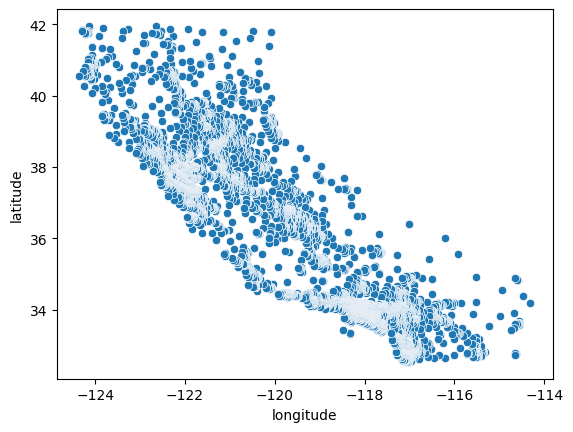

In [26]:
sns.scatterplot(data=df, x="longitude", y="latitude")

Отношение чем выше кол-во семей тем выше кол-во людей соотвественно и комнат

<Axes: xlabel='households', ylabel='population'>

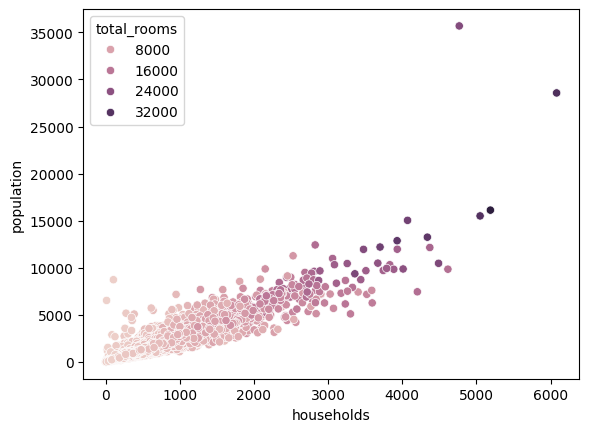

In [27]:
sns.scatterplot(data=df, x='households', y='population', hue='total_rooms')

Изменим размер графика

<Axes: xlabel='households', ylabel='population'>

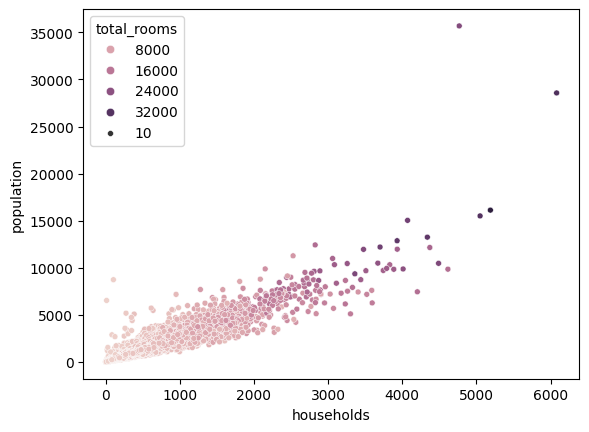

In [29]:
sns.scatterplot(data=df, x='households', y='population', hue='total_rooms', size=10)

Мы можем визуализировать сразу несколько отношений сразу используя класс PairGrid

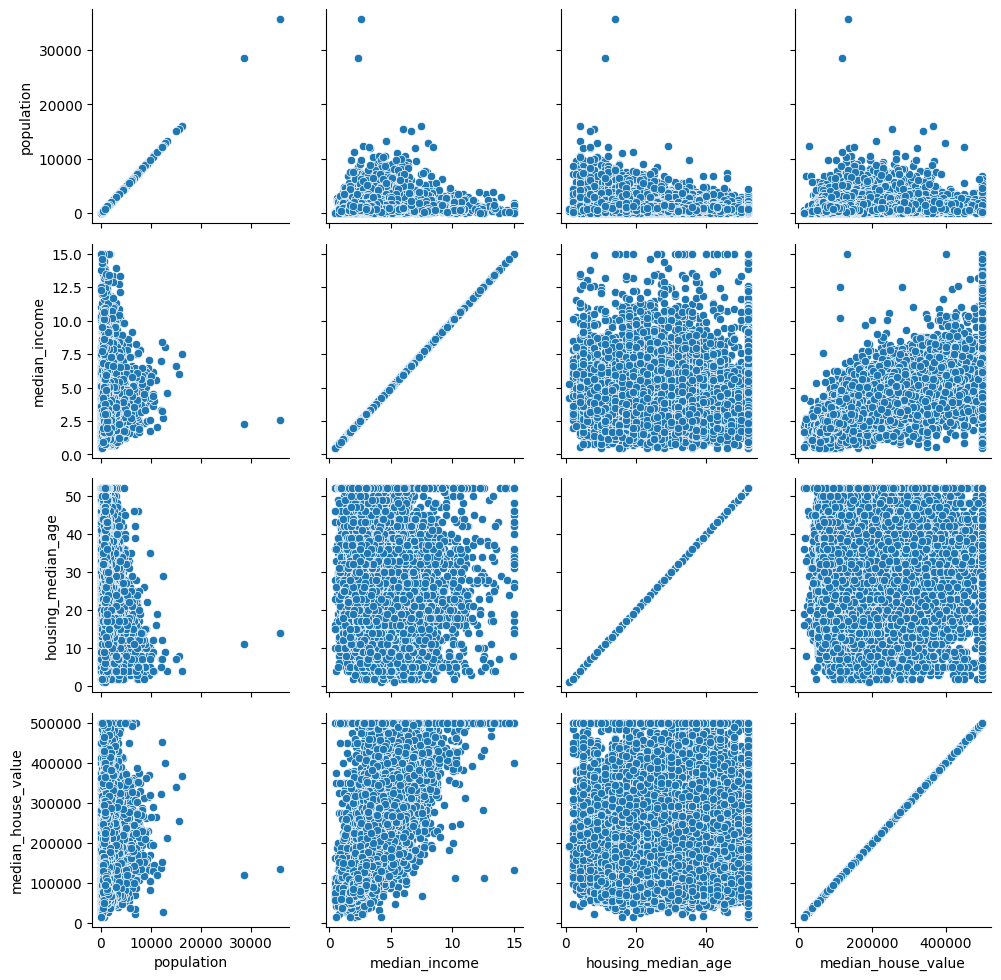

In [31]:
cols=['population', 'median_income', 'housing_median_age', 'median_house_value']
g=sns.PairGrid(df[cols])
g.map(sns.scatterplot)

Линейные графики

Хорошо подойдут если еть временная или какая-то иная последовательность
и значения которые могут меняться в зависимости от нее.

Для генерации линейных графиков используют replot

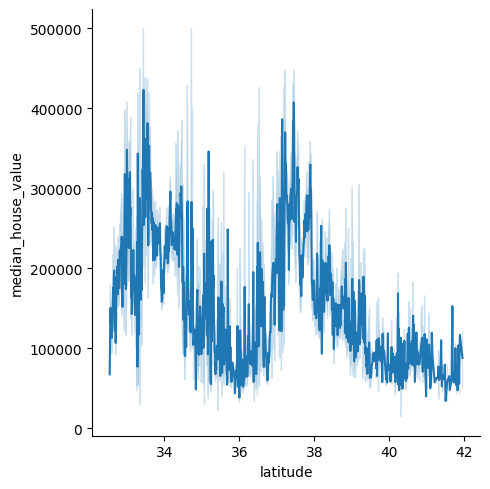

In [33]:
sns.relplot(x='latitude', y='median_house_value', kind='line', data=df)

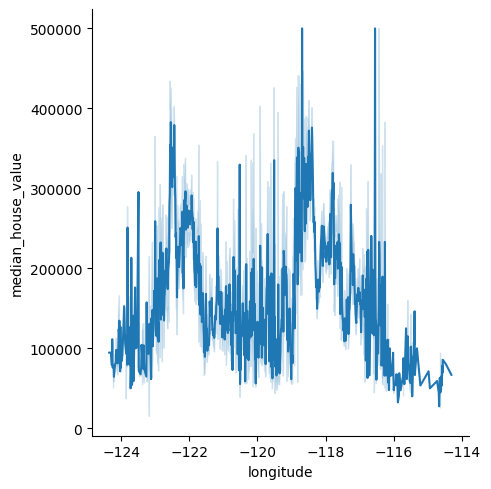

In [36]:
sns.relplot(x='longitude', y='median_house_value', kind='line', data=df)

Гистограмма

Способ представить в табличном виде также гистограмма по оси x = критерий
y = кол-во

<Axes: xlabel='median_income', ylabel='Count'>

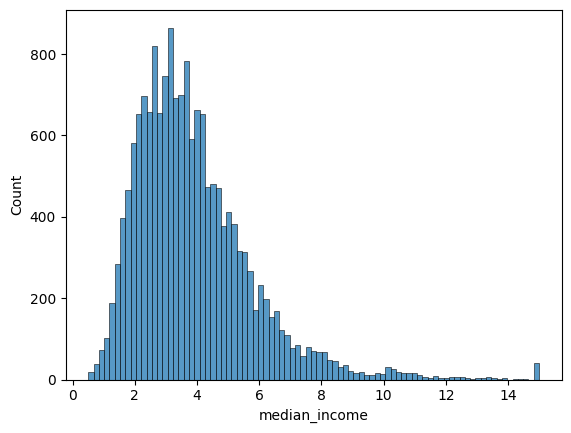

In [37]:
sns.histplot(data=df, x='median_income')

Создание сегментации

In [45]:
df.loc[df['housing_median_age'] <= 20, 'age_group'] = 'Молодые'
df.loc[(df['housing_median_age'] > 20) & (df['housing_median_age'] <= 50), 'age_group'] = 'Ср. возраст'
df.loc[df['housing_median_age'] > 50, 'age_group'] = 'Пожилые'

In [47]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,age_group
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,Молодые
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,Молодые
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,Молодые
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,Молодые
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,Молодые


Построение графика через группировку

<Axes: xlabel='age_group'>

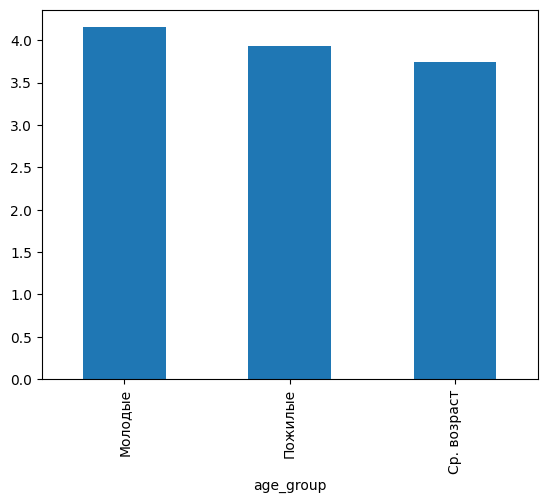

In [48]:
df.groupby('age_group')['median_income'].mean().plot(kind='bar')

In [49]:
df.loc[df['median_income'] > 6, 'income_group'] = 'rich'
df.loc[df['median_income'] < 6, 'income_group'] = 'everyone_else'

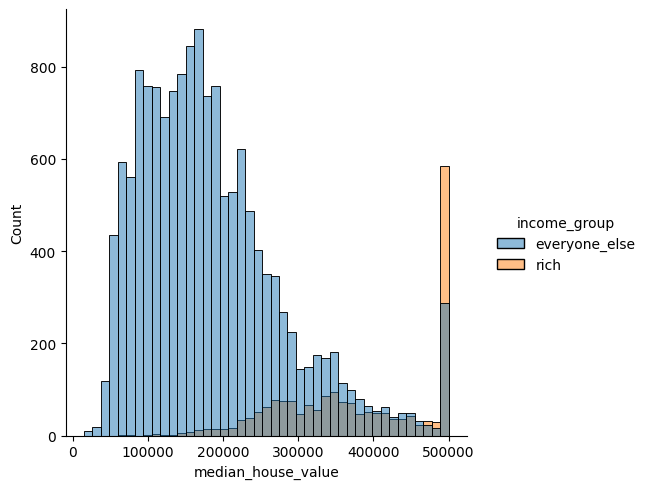

In [50]:
sns.displot(df, x="median_house_value", hue="income_group")